In [40]:
import os
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import missingno as msno
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [41]:
class Loader:
    """
    Pipeline class to batch-load, type-standardize, and consolidate NHANES SAS Transport (.XPT) files 
    into an unified cohort.
    """

    def __init__(self, target_files=None, data_folder="../sources/"):
        self.data_folder = data_folder
        self.target_files = target_files or [
            "DEMO_L", "BMX_L", "LUX_L", "ALB_CR_L", "HDL_L", "TRIGLY_L", "TCHOL_L", "CBC_L", "GHB_L", "GLU_L", 
            "BIOPRO_L", "BPQ_L", "BPXO_L", "DIQ_L", "KIQ_U_L", "SMQ_L", "MCQ_L", "DPQ_L", "RXQ_RX_L", "FNQ_L",
            "PAQ_L"
        ]

        # Core data structures to store state
        self.loaded_datasets = {}  # Map: file_prefix -> DataFrame
        self.metadata_storage = {} # Map: file_prefix -> column_labels dict
        self.master_df = None

    def batch_load(self, encoding="latin1"):
        """
        Reads local .xpt files, standardizes patient IDs, and stores metadata maps.
        """

        print("Starting batch-loading pipeline...")
        
        for file_prefix in self.target_files:
            file_name = f"{file_prefix}.xpt"
            file_path = os.path.join(self.data_folder, file_name)
                
            if os.path.exists(file_path):
                print(f"Reading local: {file_name}")
                df, meta = pyreadstat.read_xport(file_path, encoding=encoding)
                
                # Standardize SEQN (Respondent Sequence Number) for flawless multi-table joins
                if 'SEQN' in df.columns:
                    df['SEQN'] = df['SEQN'].astype(int)
                
                self.loaded_datasets[file_prefix] = df
                self.metadata_storage[file_prefix] = meta.column_names_to_labels
            else:
                print(f"Warning: File {file_name} not found in {self.data_folder}")
        
        return self
    
    def consolidate(self, anchor_file="DEMO_L"):
        """
        Execute a sequential left join anchored on demographics to preserve baseline data 
        and handle duplicate columns via safe source-specific suffixes.
        """
        if not self.loaded_datasets:
            raise ValueError("Execution Error: No dataframes have been loaded into memory yet.")
        
        if anchor_file not in self.loaded_datasets:
            raise KeyError(f"Critical Error: Anchor file '{anchor_file}' was not successfully loaded.")

        print(f"\nConsolidating cohorts... Anchoring on baseline demographics: {anchor_file}")
        
        # Initialize master cohort dataframe with baseline demographics
        self.master_df = self.loaded_datasets[anchor_file]

        # Iterate through remaining loaded files safely using dictionary key mapping
        for file_prefix, df in self.loaded_datasets.items():
            if file_prefix == anchor_file:
                continue
            
            # Left join ensures no loss of baseline demographic rows due to missing secondary files
            self.master_df = pd.merge(
                self.master_df, 
                df, 
                on='SEQN', 
                how='left', 
                suffixes=('', f'_{file_prefix}') # Prevents naming collisions by appending _FILENAME to duplicates
            )

        print(f"Success! Consolidated Master Cohort Shape: {self.master_df.shape}")
        return self.master_df

In [ ]:
class Processor:
    """
    Handles column selection, row-level filtration, and cohort isolation based on data completeness
    """

    def __init__( self,  dataframe, target_columns=None):
        self.processed_df = dataframe.copy()

        self.target_columns = target_columns or [
            # Stratification-related variables
            "SDMVSTRA", "SDMVPSU", "WTSAF2YR", "WTMEC2YR",
            
            # Demographics and baseline parameters
            "RIDEXPRG", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "BPXODI3","BMXBMI", "BMXWAIST", "BMXWT", "BMXHIP", "BMXHT",
            "BPXOSY1","BPXODI1", "BPXOSY2","BPXODI2", "BPXOSY3", "BPXOPLS1", "BPXOPLS2", "BPXOPLS3",

            # Laboratory data
            "LBDHDD", "LBXTLG", "LBDLDL", "LBXTC", "LBXPLTSI", "LBXGH", "LBXGLU", "LBXSATSI", "LBXSASSI",
            "LBXSCR", "LBXSGTSI", 

            # Questionnaire items
            "BPQ150", "DIQ010", "SMQ040", "DPQ010", "DPQ020", "DPQ030", "DPQ040", "DPQ050", "DPQ060",
            "DPQ070", "DPQ080", "DPQ090", "DPQ100", "FNQ050", "FNQ060", "FNQ080", "PAD680",

            # End-organ damage
            "LUXSMED", "URXUMA", "URDACT",

            # Chronic diseases
            "BPQ020", "BPQ150", "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F", "BPQ080", "BPQ101D", 
            "DIQ010", "DIQ050", "DIQ070", "MCQ160L", "MCQ510A", "MCQ510B", "KIQ022", "KIQ025", "RXQ033",
            "RXQ050", "DIQ160"
        ]
    
    def select_features(self):
        """
        Safely isolates specified target columns.
        """
        valid_cols = [col for col in self.target_columns if col in self.processed_df.columns]
        missing_cols = [col for col in self.target_columns if col not in self.processed_df.columns]
        
        dropped_count = len(self.target_columns) - len(valid_cols)
        if dropped_count > 0:
            print(f"Note: {dropped_count} columns requested were missing from input and skipped.")
            for col in missing_cols:
                print(col)
            print("")

        self.processed_df = self.processed_df[valid_cols]
        return self
    
    def exclude_criteria(self):
        """
        Executes clinical demographic exclusion rules. 
        """

        # Exclude patients by pregnancy status
        if "RIDEXPRG" in self.processed_df.columns:
            initial_rows = self.processed_df.shape[0]
            
            # We strictly exclude explicitly positive results (1)
            self.processed_df = self.processed_df[self.processed_df["RIDEXPRG"] != 1]
            
            # Drop the column to clean the matrix
            self.processed_df = self.processed_df.drop(columns=["RIDEXPRG"])
            
            print(f"Exclusion [Pregnancy]: Dropped {initial_rows - self.processed_df.shape[0]} active gestational records.")
        else:
            print("Note: Pregnancy marker 'RIDEXPRG' not present in current slice. Skipping exclusion.")
    
        # Isolate Adult Cohort (18 <= Age < 65)
        if "RIDAGEYR" in self.processed_df.columns:
            initial_rows_age = self.processed_df.shape[0]
            
            # Mask to filter age ranges between 18 and 64 years old
            age_mask = (self.processed_df["RIDAGEYR"] >= 18) & (self.processed_df["RIDAGEYR"] < 65)
            self.processed_df = self.processed_df[age_mask]

            print(f"Exclusion [Age Boundary]: Retained working-age adults 18-64. Dropped {initial_rows_age - self.processed_df.shape[0]} pediatric/geriatric records.")
        else:
            print("Note: Age column 'RIDAGEYR' missing. Skipping age filter step.")

        return self

    def filter_by_completeness(self, targets=None):
        """
        Ensures records retain vital clinical metrics by stripping complete anthropometric data gaps.
        """
        active_targets = targets or [
            "BMXBMI", "BMXWAIST", "BMXHIP", "BMXHT", "LBDHDD", "LBXTLG", "LBDLDL", "LBXTC", "LBXPLTSI", 
            "LBXGH", "LBXGLU", "LBXSATSI", "LBXSASSI", "LBXSCR", "LBXSGTSI", "BPQ150", "DIQ010", "SMQ040"
            ]
        
        # Filter down targets to only those present in the current dataframe slice to prevent dropna crashing
        available_targets = [t for t in active_targets if t in self.processed_df.columns]
        
        if available_targets:
            initial_rows = self.processed_df.shape[0]
            self.processed_df = self.processed_df.dropna(subset=available_targets, how="all")
            print(f"Filtration [Completeness]: Retained {self.processed_df.shape[0]} rows (Dropped {initial_rows - self.processed_df.shape[0]}).")
        else:
            print("Warning: No specified completeness targets available in data context. Skipping execution.")
            
        return self
    
    # def analytical_cohort(self, criteria_primary="WTMEC2YR", criteria_secondary="WTSAF2YR"):
    #     """
    #     Executes row-level filtration based on non-zero analytical weights.
    #     """

    #     initial_rows = self.processed_df.shape[0]

    #     if criteria_primary in self.processed_df.columns:
            
    #         # Apply primary cohort filtration rule
    #         self.cohort_primary = self.processed_df[
    #             self.processed_df[criteria_primary].notna() & (self.processed_df[criteria_primary] > 0)
    #         ]
            
    #         print(f"Filtration: [Primary cohort] Retained {self.cohort_primary.shape[0]} rows (Dropped {initial_rows - self.cohort_primary.shape[0]}).")
    #     else:
    #         print(f"Warning: Weight column '{criteria_primary}' not found. Skipping row filtration.")

    #     if criteria_secondary in self.processed_df.columns:
            
    #         # Apply secondary cohort filtration rule
    #         self.cohort_secondary = self.processed_df[
    #             self.processed_df[criteria_secondary].notna() & (self.processed_df[criteria_secondary] > 0)
    #         ]
            
    #         print(f"Filtration: [Secondary cohort] Retained {self.cohort_secondary.shape[0]} rows (Dropped {initial_rows - self.cohort_secondary.shape[0]}).")
    #     else:
    #         print(f"Warning: Weight column '{criteria_secondary}' not found. Skipping row filtration.")

    #     return self
    
    def get_data(self):
        """
        Terminator method to break out of the chain and deliver the resulting DataFrame.
        """
        return self.processed_df

In [ ]:
class Transformer:
    """
    Execute clinical feature engineering and isolates structural obesity 
    phenotypes across anthropometric ratios.
    """

    def __init__(self, dataframe):
        # Create a copy to preserve the previous state dataframe
        self.df = dataframe.copy()

    def compute_ratios(self):
        """
        Derives clinical indexes mapping to visceral adiposity equations.
        """
        # Waist-to-Hip Ratio (WHR)
        self.df["WHR"] = self.df["BMXWAIST"] / self.df["BMXHIP"]
        # Waist-to-Height Ratio (WHtR)
        self.df["WHtR"] = self.df["BMXWAIST"] / self.df["BMXHT"]
        return self
    
    def apply_criteria(self):
        """
        Maps demographic-adjusted thresholds to isolate structural adiposity
        and defines explicit, mutually exclusive obesity phenotypes.
        """
        # Ensure mandatory columns exist before evaluation
        required_cols = ["RIAGENDR", "BMXWAIST", "WHR", "WHtR", "BMXBMI"]

        if not all(col in self.df.columns for col in required_cols):
            raise KeyError("Missing essential anthropometric metrics required for classification.")
        
        # Demographics vector (1 = Male, 2 = Female)
        is_male = self.df["RIAGENDR"] == 1
        is_female = self.df["RIAGENDR"] == 2

        # Waist Circumference Thresholds (WHO Reference: Men > 102cm, Women > 88cm)
        high_wc = (is_male & (self.df["BMXWAIST"] > 102)) | (is_female & (self.df["BMXWAIST"] > 88))

        # Waist-to-Hip Ratio Thresholds (WHO Reference: Men > 0.90, Women > 0.85)
        high_whr = (is_male & (self.df["WHR"] > 0.90)) | (is_female & (self.df["WHR"] > 0.85))

        # Waist-to-Height Ratio Threshold (Universal Reference: >= 0.50)
        high_whtr = self.df["WHtR"] >= 0.50

        # Legacy Baseline (BMI >= 30)
        high_bmi = self.df["BMXBMI"] >= 30 

        # Mathematically aggregate central adiposity markers
        self.df["anthro_criteria_count"] = sum([high_wc, high_whr, high_whtr])

        # Core Algorithmic Framework Decision Rules
        rule_a = high_bmi & (self.df["anthro_criteria_count"] >= 1)
        rule_b = self.df["anthro_criteria_count"] >= 2

        # Assign final exposure cohort mapping status
        self.df["has_excess_adiposity"] = rule_a | rule_b
        
        # Define Explicit Clinical Phenotypes
        conditions = [
            (self.df["anthro_criteria_count"] >= 2) & (~high_bmi),  # Invisible Visceral Sufferers
            (high_bmi) & (self.df["anthro_criteria_count"] >= 1),   # Classic Obesity
            (~high_bmi) & (self.df["anthro_criteria_count"] < 2)    # True Controls
        ]
        choices = ["Visceral_Adiposity", "Obesity", "Healthy_Controls"]
        
        # Default captures high BMI outliers with no central adiposity features
        self.df["Obesity_Phenotype"] = np.select(conditions, choices, default="High_BMI_Low_Anthro")
        
        # Self-documenting matrix capture
        print(f"Feature Engineering Complete. Isolated {self.df['has_excess_adiposity'].sum()} patients meeting obesity criteria.")
        return self

    def get_data(self):
        """
        Resolve the transformer context and returns the enriched DataFrame.
        """
        return self.df

In [44]:
class VariablesAudit:
    """
    Evaluate data completeness patterns and map raw variable codes to human-readable clinical labels.
    """

    def __init__(self, dataframe, metadata_storage=None):
        # Create a copy to protect the upstream DataFrame from accidental mutations
        self.df = dataframe.copy()
        self.master_label_map = {}

        # Safely flatten NHANESLoader's metadata_storage into a single dictionary during instantiation
        if metadata_storage:
            for file_prefix, labels in metadata_storage.items():
                self.master_label_map.update(labels)

    def column_missingness(self, head_count=15):
        # Calculate absolute missingness and percentage across the dataset
        missing_counts = self.df.isnull().sum()
        missing_percentages = (self.df.isnull().mean() * 100)

        # Consolidate into an audit DataFrame
        missing_report = pd.DataFrame({
            "Missing_Count": missing_counts,
            "Missing_Percentage": missing_percentages
        }).sort_values(by="Missing_Percentage", ascending=False)

        # Restructure index and map structural clinical labels
        missing_report = missing_report.reset_index().rename(columns={"index": "Variable_Code"})
        missing_report["Clinical_Label"] = missing_report["Variable_Code"].map(self.master_label_map)

        # Reorder columns for readability
        missing_report = missing_report[["Variable_Code", "Clinical_Label", "Missing_Count", "Missing_Percentage"]]

        display(missing_report.head(head_count))

    def visualize_nullity(self, target_columns=None):
        """
        Forensic Audit: Visualizing data deserts to evaluate mission-specific documentation constraints.
        
        Parameters:
        - target_columns (list): Specific columns to visualize. If None, plots all columns.
        """

        # Dynamically map the target list
        if target_columns is None:
             target_columns = self.df.columns.tolist()
                
        available_keys = [v for v in target_columns if v in self.df.columns]
        
        if not available_keys:
            print("Warning: None of the specified target columns were found in the dataset.")
            return self

        print("Missingness Visualizations\n" + '-' * 40)
        
        # 1. The Nullity Matrix
        with plt.style.context('default'):
            plt.figure(figsize=(10, 6))
            msno.matrix(
                self.df[available_keys], 
                sparkline=False, 
                color=mcolors.to_rgb('#2c3e50'), # Maintains your signature dark blue hex
                fontsize=10
            )
            plt.title("Nullity Matrix: Data Presence (Dark) vs Missing (White)", fontsize=14)
            plt.show()
            
        return self
    
    def parent_child_relationship(self):
        print("DIABETES VARIABLES AUDIT")
        # Parent: DIQ010 vs Children: DIQ050 (Insulin) & DIQ070 (Pills)
        display(pd.crosstab(self.df["DIQ010"], self.df["DIQ050"].isna(), rownames=["DIQ010 (Diabetes Hx)"], colnames=["DIQ050 (Insulin) is NaN"]))
        print("\n" + "-"*50 + "\n")

        print("HYPERTENSION VARIABLES AUDIT")
        # Parent: BPQ020 vs Child: BPQ150 (Taking BP Meds)
        display(pd.crosstab(self.df["BPQ020"], self.df["BPQ150"].isna(), rownames=["BPQ020 (Hypertension Hx)"], colnames=["BPQ150 (BP Meds) is NaN"]))
        print("\n" + "-"*50 + "\n")

        print("RENAL VARIABLES AUDIT")
        # Parent: KIQ022 vs Child: KIQ025 (Received Dialysis 12mo)
        display(pd.crosstab(self.df["KIQ022"], self.df["KIQ025"].isna(), rownames=["KIQ022 (Kidney Failure Hx)"], colnames=["KIQ025 (Dialysis) is NaN"]))

In [45]:
class ClinicalEpidemiology:
    """
    Data Engineering Engine: Resolves structural missingness, maps the 2x2 clinical matrix,
    controls for geographic clusters, and visualizes epidemiological diagnostics.
    """

    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def survey_remediation(self):
        # Diabetes Remediation
        is_not_diabetic = self.df["DIQ010"].isin([2.0, 3.0])
        self.df["DIQ050"] = np.where(is_not_diabetic, 2.0, self.df["DIQ050"])
        self.df["DIQ070"] = np.where(is_not_diabetic, 2.0, self.df["DIQ070"])

        # Hypertension Remediation
        is_not_hypertensive = self.df["BPQ020"] == 2.0
        self.df["BPQ150"] = np.where(is_not_hypertensive, 2.0, self.df["BPQ150"])

        # Renal Remediation
        has_no_kidney_failure = self.df["KIQ022"] == 2.0
        self.df["KIQ025"] = np.where(has_no_kidney_failure, 2.0, self.df["KIQ025"])
        
        return self

    def clinical_vectors(self):
        # Base Vectors (History vs. Biomarker Reality)
        hx_columns = ["BPQ020", "DIQ010", "MCQ160B", "MCQ160E", "MCQ160L"]
        self.df["has_hx_chronic_disease"] = self.df[hx_columns].isin([1.0]).any(axis=1)

        renal_damage = self.df["URDACT"] >= 30
        metabolic_damage = (self.df["LBXGH"] >= 6.5) | (self.df["LBXGLU"] >= 126)
        hepatic_damage = self.df["LUXSMED"] > 7.0
        inflammatory_damage = self.df["LBXWBCSI"] > 11.0
        
        self.df["has_organ_damage"] = renal_damage | metabolic_damage | hepatic_damage | inflammatory_damage

        # Define the 2x2 Matrix Conditions
        conditions = [
            (~self.df["has_hx_chronic_disease"]) & (~self.df["has_organ_damage"]), # Healthy
            (self.df["has_hx_chronic_disease"]) & (~self.df["has_organ_damage"]),  # Controlled risk
            (~self.df["has_hx_chronic_disease"]) & (self.df["has_organ_damage"]),  # The gap
            (self.df["has_hx_chronic_disease"]) & (self.df["has_organ_damage"])    # Active organ damage
        ]

        labels = [
            "Healthy Baseline (No Hx, No Damage)",
            "Controlled Risk (Has Hx, No Damage)",
            "Diagnostic Gap (No Hx, Active Damage)",
            "Established Organ Damage (Has Hx, Active Damage)"
        ]

        self.df["Clinical_Matrix_Status"] = np.select(conditions, labels, default="Unclassified")
        self.df["undiagnosed_organ_damage"] = (~self.df["has_hx_chronic_disease"]) & self.df["has_organ_damage"]
        self.df["undiagnosed_organ_damage_int"] = self.df["undiagnosed_organ_damage"].astype(int)
        
        # FORMATTING COVARIATES: Lock in baseline references for all downstream models
        if "Obesity_Phenotype" in self.df.columns:
            self.df["Obesity_Phenotype"] = pd.Categorical(
                self.df["Obesity_Phenotype"], 
                categories=["Healthy_Controls", "Visceral_Adiposity", "Obesity", "High_BMI_Low_Anthro"],
                ordered=True
            )
        self.df["Gender_Label"] = self.df["RIAGENDR"].map({1.0: "Male", 2.0: "Female"})

        return self

    def survey_clusters(self):
        if "SDMVSTRA" in self.df.columns and "SDMVPSU" in self.df.columns:
            self.df["cluster_group"] = (10 * self.df["SDMVSTRA"]) + self.df["SDMVPSU"]
            # CRITICAL FIX: Sort contiguous memory blocks for GEE logic
            self.df = self.df.sort_values(by="cluster_group").reset_index(drop=True)
            print(f"🌍 Complex Survey Design Captured. Controlled for {self.df['cluster_group'].nunique()} geographic clusters.")
        else:
            raise KeyError("Critical complex survey variables missing.")
        return self

    def generate_table_one(self):
        print("\n📊 Table 1: Baseline Demographics of Obesity Phenotypes")
        groupby_col = "Obesity_Phenotype"
        
        table1 = self.df.groupby(groupby_col).agg(
            N_Patients=("SEQN", "count"),
            Age_Median=("RIDAGEYR", "median"),
            BMI_Median=("BMXBMI", "median"),
            Waist_Median=("BMXWAIST", "median"),
            Diagnostic_Gap_Count=("undiagnosed_organ_damage", "sum")
        ).round(1)
        
        weighted_gap = self.df[self.df["undiagnosed_organ_damage"] == True].groupby(groupby_col)["WTSAF2YR"].sum()
        total_weight = self.df.groupby(groupby_col)["WTSAF2YR"].sum()
        table1["Weighted_Gap_Prevalence (%)"] = ((weighted_gap / total_weight) * 100).round(2)

        display(table1)
        return self

    def visualize_diagnostic_gap(self):
        matrix_ct = pd.crosstab(
            self.df["Obesity_Phenotype"], 
            self.df["Clinical_Matrix_Status"], 
            normalize='index'
        ) * 100

        color_palette = {
            "Healthy Baseline (No Hx, No Damage)": "#2ecc71",       
            "Controlled Risk (Has Hx, No Damage)": "#3498db",        
            "Diagnostic Gap (No Hx, Active Damage)": "#e74c3c",      
            "Established Organ Damage (Has Hx, Active Damage)": "#8e44ad" 
        }
        ordered_cols = list(color_palette.keys())
        matrix_ct = matrix_ct[ordered_cols]

        with plt.style.context('default'):
            fig, ax = plt.subplots(figsize=(12, 7))
            matrix_ct.plot(
                kind='bar', stacked=True, 
                color=[color_palette[col] for col in ordered_cols], 
                ax=ax, edgecolor='black', width=0.6
            )
            ax.set_title("Clinical Matrix Stratification across Adiposity Phenotypes", fontsize=14, pad=15, fontweight='bold')
            ax.set_ylabel("Proportion of Sub-Cohort (%)", fontsize=12)
            ax.set_xlabel("")
            plt.xticks(rotation=0, fontsize=11)
            ax.legend(title="Clinical State", loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)
            plt.tight_layout()
            plt.show()
            
        return self

    def get_data(self):
        """Passes the pristine, clustered dataframe to the Regression Engine."""
        return self.df

In [46]:
class ClinicalRegressions:
    """
    Modeling Engine: Executes predictive epidemiological GEE and Ordinal models 
    on curated clinical matrices to prove adiposity saturation trajectories.
    """

    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def run_diagnostic_gap_gee(self):
        """
        Model 1: Modified Poisson GEE for Adjusted Prevalence Ratios (aPR).
        Bypasses Odds Ratio inflation for common cross-sectional outcomes.
        """
        print("\n📈 Model 1: Modified Poisson GEE - Adjusted Prevalence Ratios (aPR) of the Diagnostic Gap")
        formula = "undiagnosed_organ_damage_int ~ Obesity_Phenotype + RIDAGEYR + Gender_Label"
        
        # Switched from Binomial to Poisson to force a log-link for Prevalence Ratios
        model = smf.gee(
            formula,
            groups="cluster_group",
            data=self.df,
            family=sm.families.Poisson(),
            cov_struct=sm.cov_struct.Exchangeable()
        )
        result = model.fit()
        
        summary_df = pd.DataFrame({
            "aPR": np.exp(result.params),
            "Lower 95% CI": np.exp(result.conf_int()[0]),
            "Upper 95% CI": np.exp(result.conf_int()[1]),
            "P-Value": result.pvalues
        }).round(3)
        
        display(summary_df)
        return self

    def run_ordinal_progression_model(self):
        """
        Model 2: Ordinal Logit - Testing the 'Later Stage' Adiposity Hypothesis
        Maintains cumulative log-odds to test structural stage migration.
        """
        print("\n📈 Model 2: Ordinal Logit - Testing the 'Later Stage' Adiposity Hypothesis")
        
        stage_mapping = {
            "Healthy Baseline (No Hx, No Damage)": 0,
            "Controlled Risk (Has Hx, No Damage)": 1,
            "Diagnostic Gap (No Hx, Active Damage)": 1,
            "Established Organ Damage (Has Hx, Active Damage)": 2
        }
        self.df["Disease_Stage"] = self.df["Clinical_Matrix_Status"].map(stage_mapping)
        clean_df = self.df.dropna(subset=["Disease_Stage"]).copy()
        
        # Explicitly cast to integer 
        clean_df["Disease_Stage"] = clean_df["Disease_Stage"].astype(int)
        
        model = OrderedModel.from_formula(
            "Disease_Stage ~ Obesity_Phenotype + RIDAGEYR + Gender_Label",
            data=clean_df,
            distr='logit'
        )
        
        # Corrected `cov_kwds` syntax for robust clustering
        result = model.fit(method='bfgs', cov_type='cluster', cov_kwds={'groups': clean_df['cluster_group']}, disp=False)
        
        summary_df = pd.DataFrame({
            "Log Odds (Beta)": result.params,
            "Robust Std Error": result.bse,
            "P-Value": result.pvalues
        }).round(3)
        
        display(summary_df.iloc[:-2]) # Hide internal thresholds
        return self

    def run_continuous_organ_stress_gee(self, target_biomarker="LUXSMED"):
        """
        Model 3: Gaussian GEE - Continuous Biomarker Degradation
        """
        print(f"\n📈 Model 3: Gaussian GEE - Continuous Biomarker Degradation [{target_biomarker}]")
        
        # Log-transform microvascular renal stress
        if target_biomarker == "URDACT":
            self.df["biomarker_transformed"] = np.log1p(self.df["URDACT"])
            formula = "biomarker_transformed ~ Obesity_Phenotype + RIDAGEYR + Gender_Label"
        else:
            formula = f"{target_biomarker} ~ Obesity_Phenotype + RIDAGEYR + Gender_Label"
            
        model = smf.gee(
            formula,
            groups="cluster_group",
            data=self.df,
            family=sm.families.Gaussian(),
            cov_struct=sm.cov_struct.Exchangeable()
        )
        result = model.fit()
        
        summary_df = pd.DataFrame({
            "Beta": result.params,
            "Lower 95% CI": result.conf_int()[0],
            "Upper 95% CI": result.conf_int()[1],
            "P-Value": result.pvalues
        }).round(3)
        
        display(summary_df)
        return self

In [47]:
# Instantiate the data pipeline loader
loader = Loader()

# Method chaining: Load data locally and then build the master cohort 
master_dataset = loader.batch_load().consolidate()

Starting batch-loading pipeline...
Reading local: DEMO_L.xpt
Reading local: BMX_L.xpt
Reading local: LUX_L.xpt
Reading local: ALB_CR_L.xpt
Reading local: HDL_L.xpt
Reading local: TRIGLY_L.xpt
Reading local: TCHOL_L.xpt
Reading local: CBC_L.xpt
Reading local: GHB_L.xpt
Reading local: GLU_L.xpt
Reading local: BIOPRO_L.xpt
Reading local: BPQ_L.xpt
Reading local: BPXO_L.xpt
Reading local: DIQ_L.xpt
Reading local: KIQ_U_L.xpt
Reading local: SMQ_L.xpt
Reading local: MCQ_L.xpt
Reading local: DPQ_L.xpt
Reading local: RXQ_RX_L.xpt
Reading local: FNQ_L.xpt
Reading local: PAQ_L.xpt

Consolidating cohorts... Anchoring on baseline demographics: DEMO_L
Success! Consolidated Master Cohort Shape: (11933, 274)


In [48]:
# Execution Workflow
processed_dataset = (
    Processor(master_dataset)
    .select_features()
    .exclude_criteria()
    .filter_by_completeness()
    .analytical_cohort()
    .get_data()
)

Exclusion [Pregnancy]: Dropped 41 active gestational records.
Exclusion [Age Boundary]: Retained working-age adults 18-64. Dropped 6366 pediatric/geriatric records.
Filtration [Completeness]: Retained 5524 rows (Dropped 2).
Filtration: [Primary cohort] Retained 4290 rows (Dropped 1234).
Filtration: [Secondary cohort] Retained 2051 rows (Dropped 3473).


In [49]:
analytical_df = (
    PhenotypeTransformer(processed_dataset)
    .compute_ratios()
    .apply_criteria()
    .get_data()
)

Feature Engineering Complete. Isolated 2998 patients meeting obesity criteria.


In [50]:
# Instantiate the audit engine by explicitly passing your data and loader metadata
auditor = VariablesAudit(analytical_df, metadata_storage=loader.metadata_storage)

# Run the execution layer and capture the full dataframe output
missing_data_summary = auditor.column_missingness(head_count=15)

,Variable_Code,Clinical_Label,Missing_Count,Missing_Percentage
0,FNQ060,Difficulty walking 100 yds w/o equipment,5524,100.000000
1,FNQ080,Difficulty walking 100 yards,5524,100.000000
2,FNQ050,Use equip or assistance for walking,5524,100.000000
3,MCQ510B,Liver condition: Liver fibrosis,5521,99.945692
4,KIQ025,Received dialysis in past 12 months?,5409,97.918175
5,MCQ510A,Liver condition: Fatty liver,5362,97.067343
6,DIQ050,Taking insulin now,5008,90.658943
7,DIQ070,Take diabetic pills to lower blood sugar,4344,78.638668
8,BPQ150,Taking high blood pressure medication,4094,74.112962
9,BPQ150,Taking high blood pressure medication,4094,74.112962


Missingness Visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

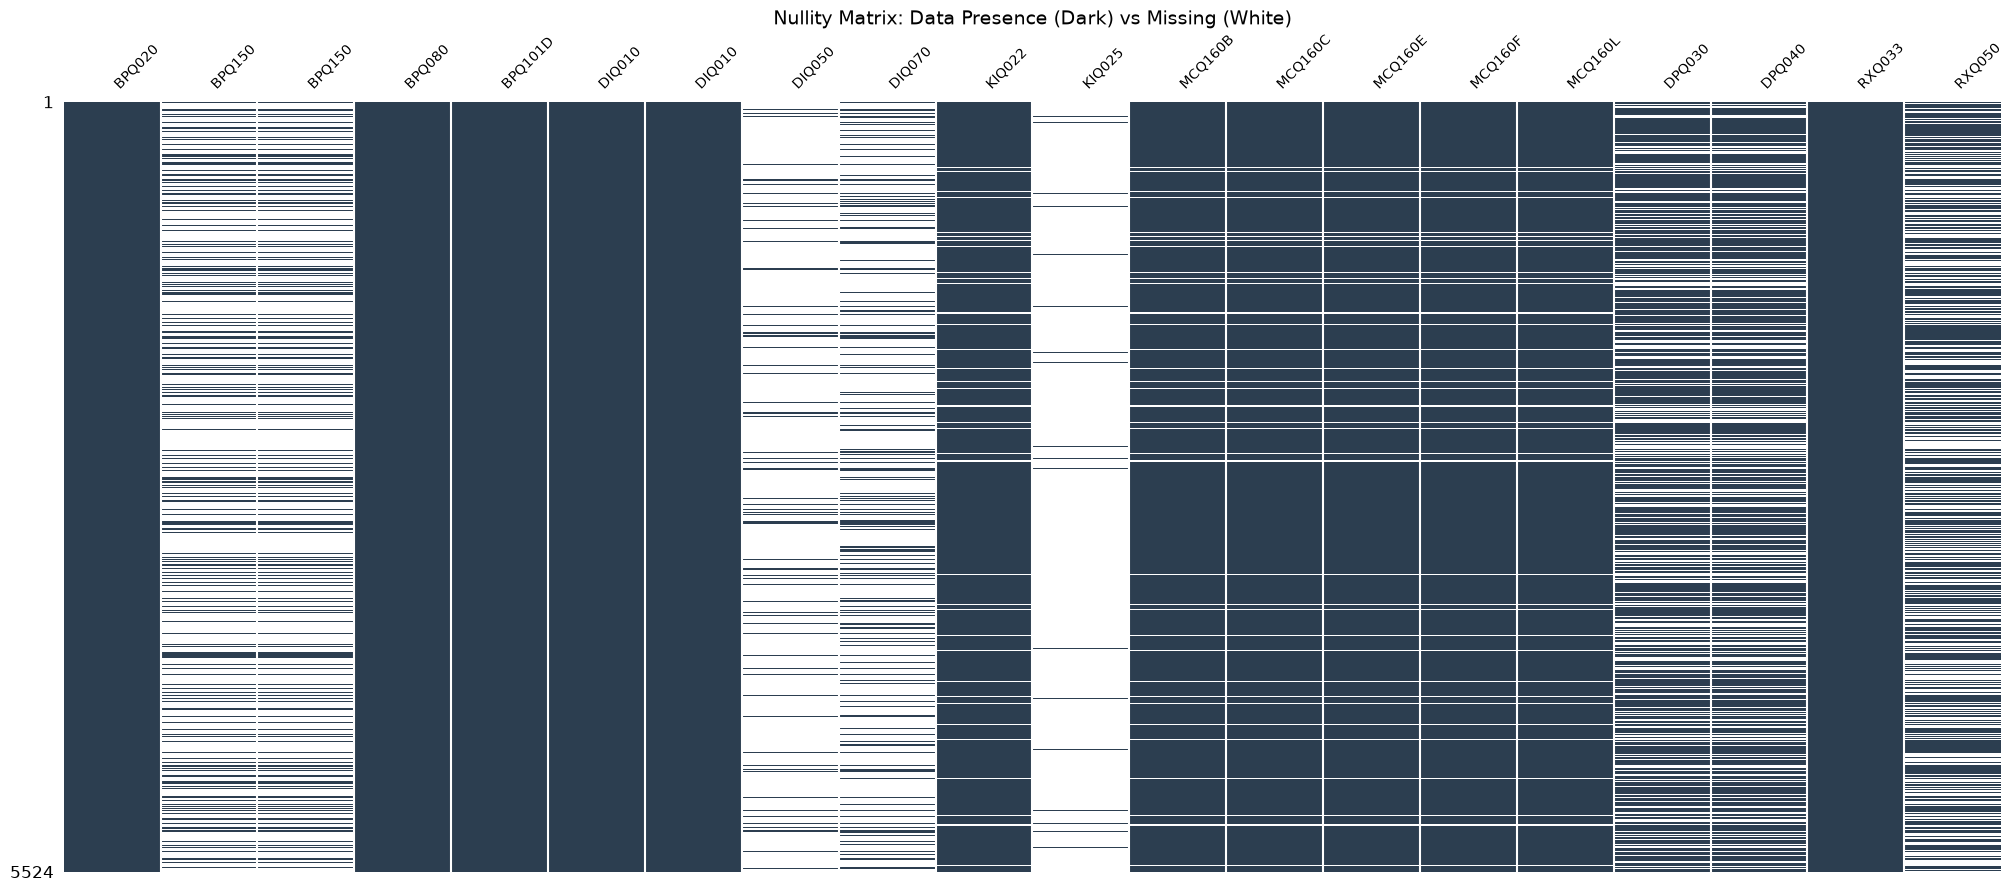

DIABETES VARIABLES AUDIT


ValueError: Data must be 1-dimensional, got ndarray of shape (5524, 2) instead

In [51]:
# 2. Pass your curated end-organ damage list to the visualizer
questionnaires = [
    "BPQ020", "BPQ150", "BPQ080", "BPQ101D", "DIQ010", "DIQ050", "DIQ070", "KIQ022", "KIQ025", "MCQ010",
            "MCQ160B", "MCQ160C", "MCQ160E", "MCQ160F", "MCQ160M", "MCQ160L", "DPQ030", "DPQ040", "RXQ033", "RXQ050"
]
auditor.visualize_nullity(target_columns=questionnaires)
auditor.parent_child_relationship()

🌍 Complex Survey Design Captured. Controlled for 30 geographic clusters.

📊 Table 1: Baseline Demographics of Obesity Phenotypes


,N_Patients,Age_Median,BMI_Median,Waist_Median,Diagnostic_Gap_Count,Weighted_Gap_Prevalence (%)
Obesity_Phenotype,,,,,,
Healthy_Controls,570,34.0,22.8,80.5,50,7.47
Visceral_Adiposity,639,51.0,26.8,94.3,58,10.27
Obesity,800,47.5,35.0,113.1,148,18.67
High_BMI_Low_Anthro,27,46.0,43.7,NaN,6,23.13


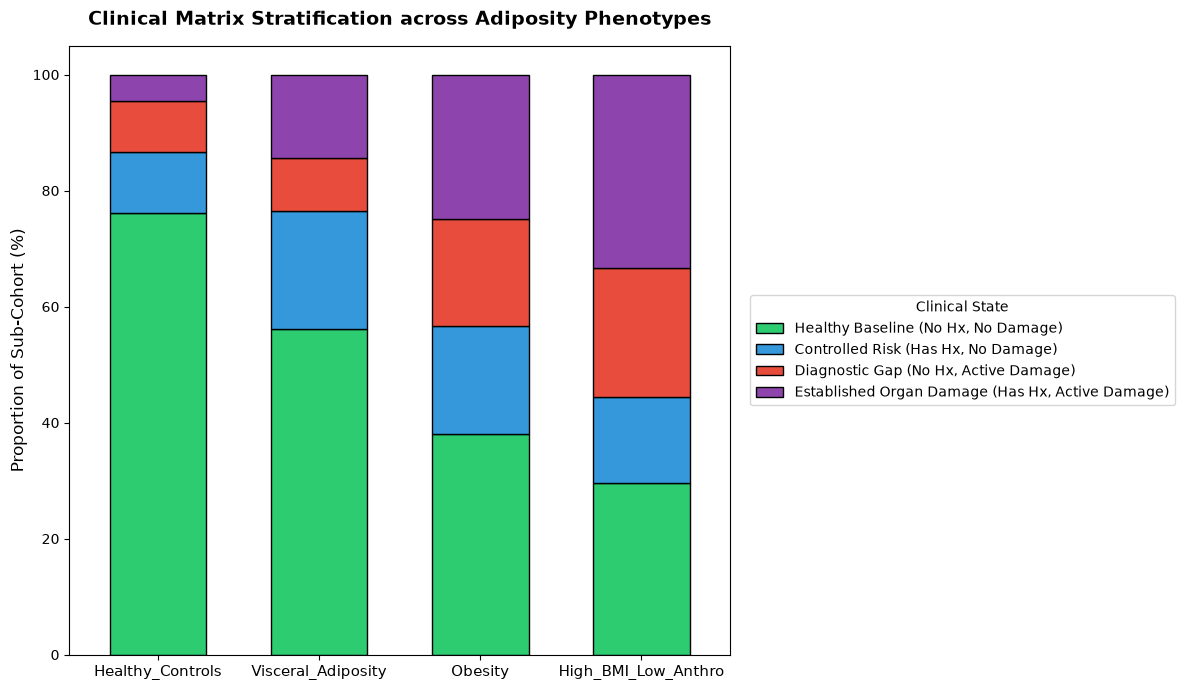

In [ ]:
# Instantiate and execute the complete analytics engine
engine_prep = (
    ClinicalEpidemiology(analytical_df)
    .survey_remediation()
    .clinical_vectors()
    .survey_clusters()
    .generate_table_one()
    .visualize_diagnostic_gap()
)

In [ ]:
# 2. Hand-off the pristine matrix to Model Executions
engine_models = (
    ClinicalRegressions(engine_prep.get_data())
    .run_diagnostic_gap_gee()
    .run_ordinal_progression_model()
    .run_continuous_organ_stress_gee("LUXSMED")  # Liver Stress 
    .run_continuous_organ_stress_gee("URDACT")   # Renal Stress
    .run_continuous_organ_stress_gee("LBXGH")
)


📈 Model 1: Modified Poisson GEE - Adjusted Prevalence Ratios (aPR) of the Diagnostic Gap


,aPR,Lower 95% CI,Upper 95% CI,P-Value
Intercept,0.136,0.080,0.230,0.000
Obesity_Phenotype[T.Visceral_Adiposity],1.205,0.891,1.630,0.226
Obesity_Phenotype[T.Obesity],2.361,1.815,3.071,0.000
Obesity_Phenotype[T.High_BMI_Low_Anthro],3.025,1.643,5.569,0.000
Gender_Label[T.Male],1.013,0.803,1.278,0.910
RIDAGEYR,0.988,0.979,0.997,0.006



📈 Model 2: Ordinal Logit - Testing the 'Later Stage' Adiposity Hypothesis


,Log Odds (Beta),Robust Std Error,P-Value
Obesity_Phenotype[T.Visceral_Adiposity],0.434,0.121,0.000
Obesity_Phenotype[T.Obesity],1.384,0.120,0.000
Obesity_Phenotype[T.High_BMI_Low_Anthro],1.725,0.288,0.000
Gender_Label[T.Male],0.217,0.095,0.022
RIDAGEYR,0.052,0.004,0.000



📈 Model 3: Gaussian GEE - Continuous Biomarker Degradation [LUXSMED]


,Beta,Lower 95% CI,Upper 95% CI,P-Value
Intercept,2.836,2.016,3.656,0.000
Obesity_Phenotype[T.Visceral_Adiposity],0.097,-0.345,0.540,0.666
Obesity_Phenotype[T.Obesity],2.154,1.690,2.617,0.000
Obesity_Phenotype[T.High_BMI_Low_Anthro],12.037,4.358,19.717,0.002
Gender_Label[T.Male],1.209,0.693,1.725,0.000
RIDAGEYR,0.038,0.020,0.057,0.000



📈 Model 3: Gaussian GEE - Continuous Biomarker Degradation [URDACT]


,Beta,Lower 95% CI,Upper 95% CI,P-Value
Intercept,1.799,1.696,1.903,0.000
Obesity_Phenotype[T.Visceral_Adiposity],0.024,-0.057,0.106,0.560
Obesity_Phenotype[T.Obesity],0.196,0.104,0.288,0.000
Obesity_Phenotype[T.High_BMI_Low_Anthro],0.437,-0.113,0.987,0.119
Gender_Label[T.Male],-0.073,-0.164,0.018,0.114
RIDAGEYR,0.008,0.005,0.010,0.000



📈 Model 3: Gaussian GEE - Continuous Biomarker Degradation [LBXGH]


,Beta,Lower 95% CI,Upper 95% CI,P-Value
Intercept,4.582,4.460,4.705,0.000
Obesity_Phenotype[T.Visceral_Adiposity],0.088,-0.030,0.206,0.143
Obesity_Phenotype[T.Obesity],0.405,0.252,0.558,0.000
Obesity_Phenotype[T.High_BMI_Low_Anthro],0.728,0.251,1.206,0.003
Gender_Label[T.Male],0.154,0.072,0.236,0.000
RIDAGEYR,0.018,0.015,0.022,0.000
